# Behaviour PLS for ERP data

Here we use a single participant from the "kiloword dataset" ([Dufau et al., 2015](https://doi.org/10.1177/0956797615603934)) to demonstrate how behaviour PLS can be used to measure multivariate associations between ERP data and experimental covariates (in this case, various features of words presented to participants). It is valuable to compare this to the [MNE tutorial analyzing the same data using linear regression](https://mne.tools/stable/auto_examples/stats/sensor_regression.html).

## Loading and inspecting the data

The kiloword dataset ships with MNE and can be loaded as follows:

In [1]:
import mne
from mne.datasets import kiloword

# Load the data
path = kiloword.data_path() / "kword_metadata-epo.fif"
epochs = mne.read_epochs(path)

Reading C:\Users\isaac\mne_data\MNE-kiloword-data\kword_metadata-epo.fif ...
Isotrak not found


C:\Users\isaac\Projects\mne-plsc\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    Found the data of interest:
        t =    -100.00 ...     920.00 ms
        0 CTF compensation matrices available
Adding metadata with 8 columns
960 matching events found
No baseline correction applied
0 projection items activated


The `epochs` variable contains ERP data for a single participant along with metadata with various features of the words presented per trial:

In [2]:
epochs.metadata

,WORD,Concreteness,WordFrequency,OrthographicDistance,NumberOfLetters,BigramFrequency,ConsonantVowelProportion,VisualComplexity
0,film,5.450000,3.189490,1.75,4.0,343.250,0.750,55.783710
1,cent,5.900000,3.700704,1.35,4.0,546.750,0.750,63.141553
2,shot,4.600000,2.858537,1.20,4.0,484.750,0.750,64.600033
3,cold,3.700000,3.454540,1.15,4.0,1095.250,0.750,63.657457
4,main,3.000000,3.539076,1.35,4.0,686.000,0.500,68.945661
...,...,...,...,...,...,...,...,...
955,drudgery,3.473684,1.556303,2.95,8.0,486.125,0.625,69.732357
956,reversal,3.700000,1.991226,2.65,8.0,859.000,0.625,60.545879
957,billiard,5.500000,1.672098,2.90,8.0,528.875,0.625,55.838597
958,adherent,3.450000,0.698970,2.55,8.0,615.625,0.625,68.088112


## Analyzing associations

We will examine associations between ERP data and several features of the words presented. To do so, we can fit a behaviour PLS model using the `metadata` attribute as the design matrix and specifying the column names containing the covariates we want to examine:

In [3]:
import mne_plsc

res = mne_plsc.fit_beh(epochs,
                       design=epochs.metadata,
                       covariates=['Concreteness', 'WordFrequency'])

We can then visualize the latent variables from the resulting model fit. As we can see, the first latent variable is most strongly related to word frequency and the second is most strongly related to concreteness:

(<Figure size 640x480 with 3 Axes>,
 array([<Axes: >, <Axes: xlabel='Time (s)', ylabel='Salience'>],
       dtype=object))

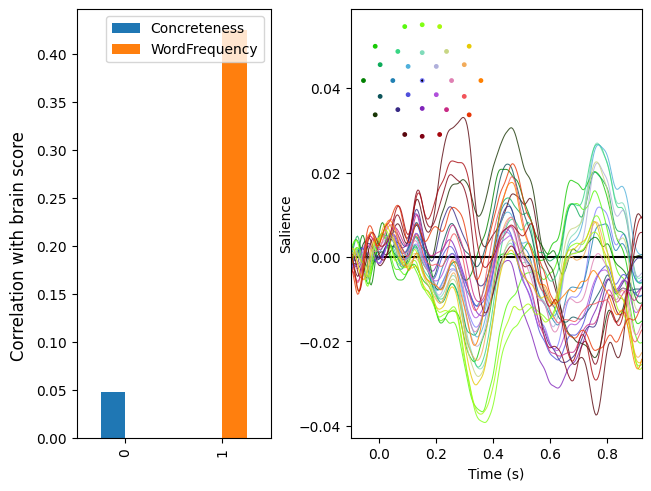

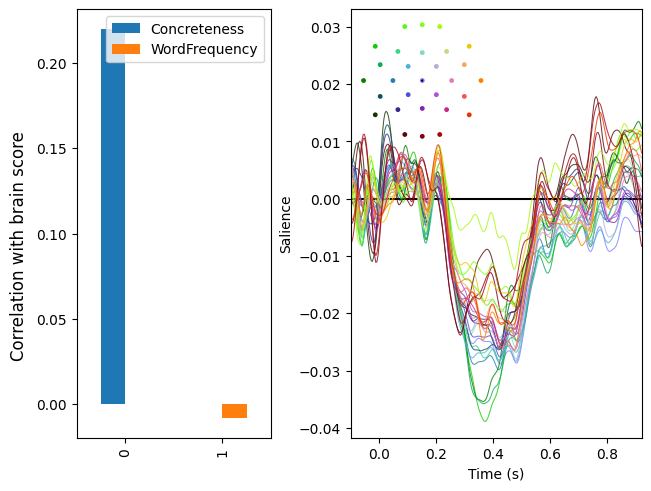

In [6]:
res.plot_lv(0, which='saliences')
res.plot_lv(1, which='saliences')

Compare the pattern of saliences in the second latent variable to the pattern of regression weights identified by linear regression [here](https://mne.tools/stable/auto_examples/stats/sensor_regression.html). Their time course is quite similar

In [8]:
res.model.bootstrap(100, return_boot_stat_dist=False)

Resampling: 100%|█████████████████████████████████████████████████████████████████████████████████| 100/100 [00:15<00:00,  6.38it/s]


In [9]:
res.add_adjacency()
res.cluster()

Defaulting to all channels adjacent for ERP/ERF analysis
Computing clusters for lv_idx 0...
3 clusters
Computing clusters for lv_idx 1...
8 clusters


(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='Cluster index', ylabel='Cluster size (% of strong saliences)'>)

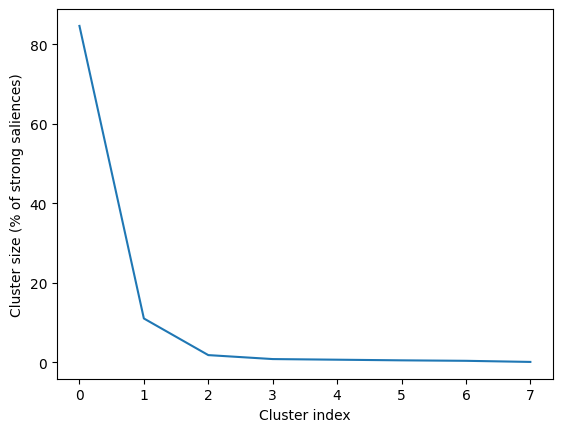

In [10]:
res.plot_cluster_sizes(lv_idx=1)

C:\Users\isaac\Projects\mne-plsc\src\mne_plsc\viz.py:354: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  if cluster_info['which'] == 'saliences':


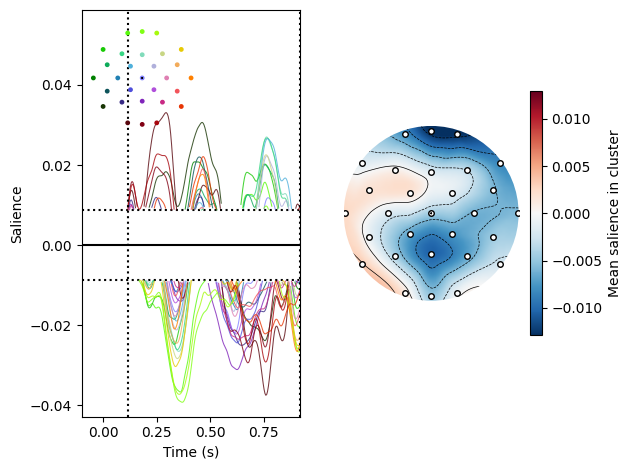

In [11]:
res.plot_clusters(lv_idx=0, cluster_idx=0)